In [43]:
import sqlite3
import os
from datetime import datetime, date
import pandas as pd

In [44]:
df = pd.read_csv("weekly_finance_collection_payment_behaviour.csv")

In [45]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nPayment_Risk distribution:")
print(df['Payment_Risk'].value_counts())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (5000, 18)

Columns: ['Customer_ID', 'Customer_Name', 'Loan_Amount', 'Interest_Rate_Percent', 'Interest_Amount', 'Total_Payable', 'Weekly_Due', 'Total_Weeks', 'Week_Number', 'Amount_Paid', 'Due_Date', 'Payment_Date', 'Days_Late', 'Remaining_Balance', 'Previous_Late_Count', 'Missed_Payments', 'Payment_Status', 'Payment_Risk']

Payment_Risk distribution:
Payment_Risk
Medium    2742
High      1343
Low        915
Name: count, dtype: int64

Missing values:
Customer_ID                0
Customer_Name              0
Loan_Amount                0
Interest_Rate_Percent      0
Interest_Amount            0
Total_Payable              0
Weekly_Due                 0
Total_Weeks                0
Week_Number                0
Amount_Paid                0
Due_Date                   0
Payment_Date             481
Days_Late                  0
Remaining_Balance          0
Previous_Late_Count        0
Missed_Payments            0
Payment_Status             0
Payment_Risk               0
dtype: int64


In [46]:
df['Payment_Date'] = df['Payment_Date'].fillna('Missed')

In [47]:
df['Due_Date'] = pd.to_datetime(df['Due_Date'], errors='coerce')
df['Payment_Date'] = pd.to_datetime(df['Payment_Date'], errors='coerce')

In [48]:
df['Payment_Ratio'] = df['Amount_Paid'] / (df['Weekly_Due'] + 1e-6)

In [49]:
df['Balance_Ratio'] = df['Remaining_Balance'] / (df['Total_Payable'] + 1e-6)

In [50]:
df['Week_Progress'] = df['Week_Number'] / df['Total_Weeks']

In [51]:
df['Is_Partial'] = (df['Amount_Paid'] > 0) & (df['Amount_Paid'] < df['Weekly_Due'] * 0.95)

In [52]:
feature_cols = [
    'Loan_Amount',
    'Interest_Rate_Percent',
    'Interest_Amount',
    'Total_Payable',
    'Weekly_Due',
    'Total_Weeks',
    'Week_Number',
    'Amount_Paid',
    'Days_Late',
    'Remaining_Balance',
    'Previous_Late_Count',
    'Missed_Payments',
    'Payment_Ratio',
    'Balance_Ratio',
    'Week_Progress',
    'Is_Partial'
]

X = df[feature_cols].copy()
y = df['Payment_Risk'].copy()

In [53]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("\nClasses:", le.classes_)

NameError: name 'LabelEncoder' is not defined

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

In [ ]:
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 4000, Test size: 1000


In [ ]:
        models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.08,
        max_depth=5,
        random_state=42
    )
}

In [ ]:
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"Accuracy : {acc:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    results[name] = {
        'model': model,
        'accuracy': acc,
        'f1': f1,
        'y_pred': y_pred
    }


Training: Logistic Regression
Accuracy : 0.9210
F1-score : 0.9223

Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.93      0.86       269
         Low       1.00      1.00      1.00       183
      Medium       0.96      0.89      0.92       548

    accuracy                           0.92      1000
   macro avg       0.92      0.94      0.93      1000
weighted avg       0.93      0.92      0.92      1000


Training: Random Forest
Accuracy : 1.0000
F1-score : 1.0000

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       269
         Low       1.00      1.00      1.00       183
      Medium       1.00      1.00      1.00       548

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Training: Gradient Boosting
Accuracy : 1.0000
F1-score : 1.00

In [ ]:
best_name = max(results, key=lambda k: results[k]['f1'])
best_model = results[best_name]['model']
print(f"\n>>> Best model: {best_name} (F1 = {results[best_name]['f1']:.4f})")


>>> Best model: Random Forest (F1 = 1.0000)


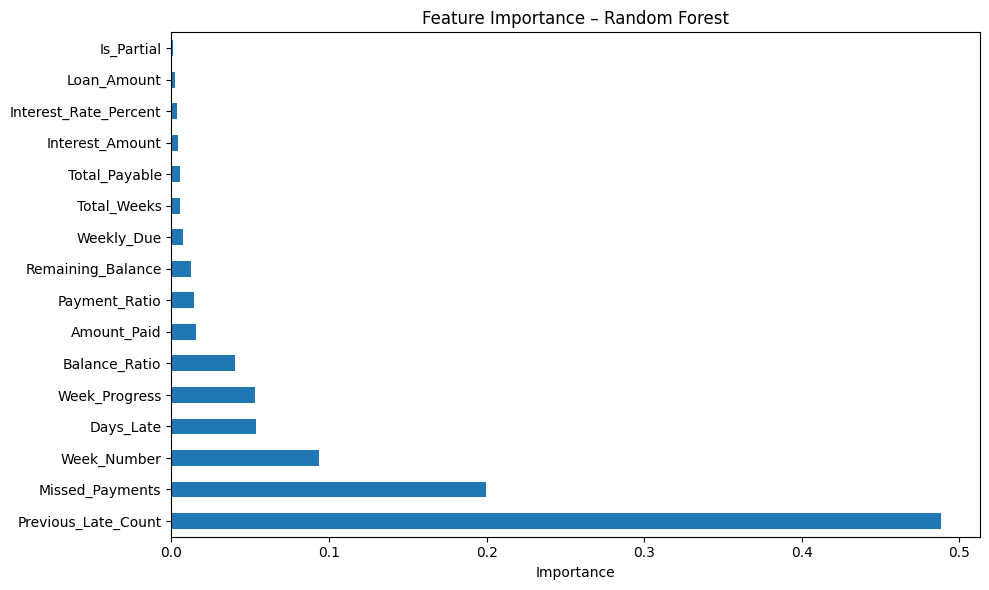


Top features:
Previous_Late_Count    0.488625
Missed_Payments        0.199928
Week_Number            0.093694
Days_Late              0.053519
Week_Progress          0.053021
Balance_Ratio          0.040269
Amount_Paid            0.015546
Payment_Ratio          0.014261
Remaining_Balance      0.012268
Weekly_Due             0.007199
dtype: float64


In [ ]:
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=feature_cols)
    imp = imp.sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    imp.plot(kind='barh')
    plt.title(f'Feature Importance – {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    print("\nTop features:")
    print(imp.head(10))

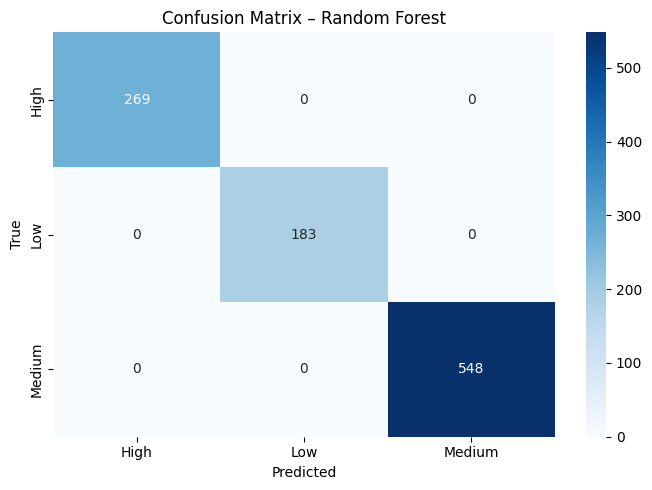

In [ ]:
y_pred_best = results[best_name]['y_pred']
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix – {best_name}')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
print("\n5-Fold Cross-Validation (F1 weighted):")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X, y_encoded, cv=cv, scoring='f1_weighted', n_jobs=-1)
    print(f"{name:25s} → {scores.mean():.4f} ± {scores.std():.4f}")


5-Fold Cross-Validation (F1 weighted):
Logistic Regression       → 0.9142 ± 0.0104
Random Forest             → 0.9994 ± 0.0012
Gradient Boosting         → 1.0000 ± 0.0000


In [ ]:
import joblib
joblib.dump({
    'model': best_model,
    'label_encoder': le,
    'features': feature_cols
}, 'payment_risk_model.pkl')

print("\nModel saved as → payment_risk_model.pkl")


Model saved as → payment_risk_model.pkl


In [ ]:
import joblib
import pandas as pd

saved = joblib.load('payment_risk_model.pkl')
model = saved['model']
le = saved['label_encoder']
features = saved['features']

new_data = pd.DataFrame([{
    'Loan_Amount': 10000,
    'Interest_Rate_Percent': 20.0,
    'Interest_Amount': 2000.0,
    'Total_Payable': 12000.0,
    'Weekly_Due': 600.0,
    'Total_Weeks': 20,
    'Week_Number': 7,
    'Amount_Paid': 0.0,
    'Days_Late': 12,
    'Remaining_Balance': 7800.0,
    'Previous_Late_Count': 1,
    'Missed_Payments': 1,
    'Payment_Ratio': 0.0,
    'Balance_Ratio': 0.65,
    'Week_Progress': 0.35,
    'Is_Partial': False
}])

pred = model.predict(new_data[features])
print("Predicted Risk:", le.inverse_transform(pred)[0])

Predicted Risk: Medium
